In [52]:
import pandas as pd
from tokenizers import Tokenizer
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
df_eval = pd.read_csv('data/eval.csv')

In [13]:
df_train.head()

,en,pt,en_length,pt_length,en_max_len_word,pt_max_len_word
0,Are you talking about this suburban bullshit f...,Você está falando sobre essa besteira de fanta...,111,120,8,11
1,You'll be free as soon as the new organization...,Você estará livre assim que a nova organização...,111,111,12,12
2,Every time you see one of us either in uniform...,Toda vez que você ver um de nos em um uniforme...,131,124,11,11
3,"On the other hand, if i hadn't come here alone...","Por outro lado,... se não tivesse vindo sozinh...",110,120,6,10
4,"Your majesty, my lord hertford, and other coun...",Majestade... lorde hertford e os outros consel...,133,142,12,13


In [ ]:
tokenizer = Tokenizer.from_file('artifacts/tokenizer.json')

In [11]:
tokenizer.encode('Olá mundo, meu nome é João').tokens

['O', 'lá ', 'mundo, ', 'meu ', 'nome é ', 'Jo', 'ão']

In [12]:
tokenizer.encode('Olá mundo, meu nome é João').ids

[45, 1580, 4599, 762, 19273, 9977, 2220]

In [42]:
vocabs_sizes = [500, 1000, 2000, 5000, 10000, 20000, 30000]


print('Declaring tokenizer...')
for vocab_size in tqdm([500, 1000, 5000, 10000, 25000, 30000, 50000]):
    tokenizer = Tokenizer.from_file(f'artifacts/tokenizer_{vocab_size}.json')
    
    df_train[f'len_tokens_{vocab_size}'] = df_train['en'].apply(lambda x: len(tokenizer.encode(x).ids))

    df_train[f'compress_{vocab_size}'] = df_train.apply(lambda x: x[f'len_tokens_{vocab_size}'] / x['en_length'], axis=1)

Declaring tokenizer...


100%|██████████| 7/7 [01:02<00:00,  8.91s/it]


In [56]:
columns_compress = [x for x in df_train.columns if 'compress' in x]
rename_columns = {x: x.replace('compress_', '') for x in columns_compress}
df_stats = df_train[columns_compress].rename(columns=rename_columns).describe()
df_stats

,500,1000,5000,10000,25000,30000,50000
count,313221.000000,313221.000000,313221.000000,313221.000000,313221.000000,313221.000000,313221.000000
mean,0.468297,0.374318,0.279150,0.257549,0.239502,0.237142,0.231887
std,0.032400,0.033474,0.028232,0.027058,0.026790,0.026903,0.027276
min,0.330275,0.241667,0.176991,0.163462,0.141509,0.141509,0.136752
25%,0.446429,0.351724,0.259615,0.238806,0.221154,0.218487,0.212963
50%,0.467290,0.373333,0.277372,0.256098,0.237762,0.235714,0.230263
75%,0.490196,0.396040,0.296875,0.274336,0.256410,0.254237,0.248447
max,0.836538,0.836538,0.836538,0.836538,0.836538,0.836538,0.836538


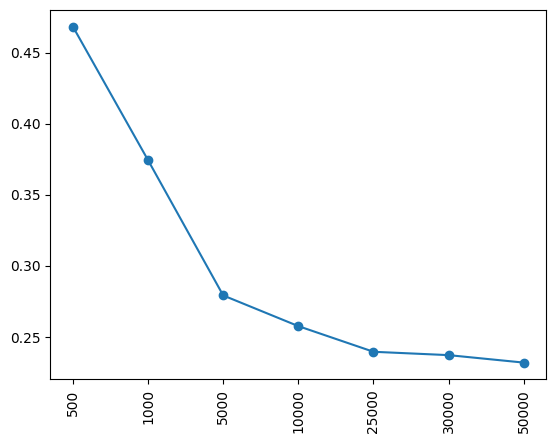

In [57]:
df_stats.T['mean'].plot.line(marker='o')
plt.xticks(rotation=90)
plt.show()

In [44]:
columns_tokens = [x for x in df_train.columns if 'len_tokens_' in x]
df_train[columns_tokens].describe()


,len_tokens_500,len_tokens_1000,len_tokens_5000,len_tokens_10000,len_tokens_25000,len_tokens_30000,len_tokens_50000
count,313221.000000,313221.000000,313221.000000,313221.000000,313221.000000,313221.000000,313221.000000
mean,56.880471,45.464244,33.893471,31.258536,29.056838,28.768515,28.126930
std,8.816212,7.493856,5.733829,5.286115,4.970127,4.939473,4.884507
min,35.000000,25.000000,19.000000,17.000000,15.000000,15.000000,15.000000
25%,50.000000,40.000000,30.000000,27.000000,25.000000,25.000000,25.000000
50%,55.000000,44.000000,33.000000,30.000000,28.000000,28.000000,27.000000
75%,62.000000,50.000000,37.000000,34.000000,32.000000,32.000000,31.000000
max,114.000000,111.000000,100.000000,99.000000,90.000000,90.000000,90.000000
